# End-to-End License Plate Recognition (LPR) System
### Deep Learning Capstone Project — Indian Vehicles

## Problem Statement
Manual vehicle identification for tasks like toll collection, traffic monitoring, and law
enforcement is slow and error-prone at scale. This project builds an **end-to-end, real-time
Automatic License Plate Recognition (ALPR) pipeline** for Indian vehicles using a **two-stage
deep learning architecture**:

1. **Detection Stage** — YOLO-based object detector locates the license plate region in an image/frame.
2. **Recognition Stage** — An OCR model (transformer-based) reads the alphanumeric text from the cropped plate.

The system is trained and evaluated on an Indian license plate dataset, optimized for real-time
inference, and evaluated using detection (mAP, IoU) and recognition (character accuracy, plate
accuracy) metrics. Target use cases: **toll collection, traffic monitoring, automated vehicle
identification.**

## Workflow
1. Vehicle identification need → automated LPR
2. Architecture: end-to-end LPR pipeline — Detection → Recognition
3. DL Models: YOLO (plate detection) + Transformer OCR (text recognition)
4. Dataset: Indian license plate dataset (~8-9k images)
5. Data preprocessing & character segmentation
6. Two-stage architecture (Detection model + Recognition model, trained separately)
7. Training & optimization
8. Real-time LPR performance metrics & accuracy
9. Deployment considerations: traffic monitoring, toll collection


## 1. Environment Setup
Install the required libraries: `ultralytics` (YOLOv8) for detection, `easyocr` and `transformers` (TrOCR) for recognition, `kagglehub` to pull the real dataset, plus standard CV/DS tooling.

In [1]:
# Run once
!pip install ultralytics easyocr transformers opencv-python-headless pillow matplotlib pandas scikit-learn kagglehub -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 32.0 MB/s eta 0:00:00


In [2]:
import os
import cv2
import glob
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
print("CUDA available:", torch.cuda.is_available())


CUDA available: True


## 2. Dataset

This notebook uses the real **[Indian licence plate](https://www.kaggle.com/datasets/gauravsanwal/indian-licence-plate)** dataset by Gaurav Sanwal on Kaggle — Indian vehicle images with license-plate bounding boxes provided as YOLO-format `.txt` annotations.

**Getting Kaggle access set up (one-time):**
1. Create a Kaggle account if you don't have one, then go to `Account -> Create New API Token` to download `kaggle.json`.
2. Either place it at `~/.kaggle/kaggle.json`, or set the `KAGGLE_USERNAME` / `KAGGLE_KEY` environment variables before running the next cell. `kagglehub` will also prompt for these interactively if it can't find credentials.

The cells below:
1. Download the dataset via `kagglehub`.
2. Auto-discover image/label pairs (the raw download's internal layout can vary, so we search recursively rather than assuming a fixed structure).
3. Split into train/val/test (80/10/10) and copy them into the YOLO folder layout below.
4. Generate `data.yaml` for `ultralytics`.

**Note on OCR ground truth:** this dataset provides plate *bounding boxes*, not the plate *text* — so it's directly usable for Stage 1 (detection) training/eval. For Stage 2 (recognition) exact-match evaluation in Section 8, you'll need a small hand-labeled `(image_path, ground_truth_plate)` CSV of your own, since no transcribed plate text ships with this dataset.

```
data/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
└── labels/
    ├── train/    # YOLO .txt: class x_center y_center width height (normalized)
    ├── val/
    └── test/
```


In [3]:
DATA_DIR = Path("data")
IMAGES_DIR = DATA_DIR / "images"
LABELS_DIR = DATA_DIR / "labels"

for split in ["train", "val", "test"]:
    (IMAGES_DIR / split).mkdir(parents=True, exist_ok=True)
    (LABELS_DIR / split).mkdir(parents=True, exist_ok=True)


In [4]:
# Download the real dataset from Kaggle:
# https://www.kaggle.com/datasets/gauravsanwal/indian-licence-plate
import kagglehub

DATASET_SLUG = "gauravsanwal/indian-licence-plate"
raw_path = Path(kagglehub.dataset_download(DATASET_SLUG))
print("Downloaded dataset to:", raw_path)

# Peek at what's inside so we know how it's laid out
all_files = list(raw_path.rglob("*"))
print(f"Total files/dirs found: {len(all_files)}")
for p in sorted(all_files)[:30]:
    print(" ", p.relative_to(raw_path))


100%|██████████| 368M/368M [00:03<00:00, 121MB/s]

Extracting files...


Downloaded dataset to: /root/.cache/kagglehub/datasets/gauravsanwal/indian-licence-plate/versions/1
Total files/dirs found: 16847
  licence plate.v1i.darknet
  licence plate.v1i.darknet/README.dataset.txt
  licence plate.v1i.darknet/README.roboflow.txt
  licence plate.v1i.darknet/test
  licence plate.v1i.darknet/test/0011d11a6a5ab5ad_jpg.rf.b78cbabe40a097b9fee5e87e5a620831.jpg
  licence plate.v1i.darknet/test/0011d11a6a5ab5ad_jpg.rf.b78cbabe40a097b9fee5e87e5a620831.txt
  licence plate.v1i.darknet/test/0021af0b921af690_jpg.rf.772887bfdb30020d625312703ccd5394.jpg
  licence plate.v1i.darknet/test/0021af0b921af690_jpg.rf.772887bfdb30020d625312703ccd5394.txt
  licence plate.v1i.darknet/test/00293842c1405567_jpg.rf.7aece134bb8ffdb340f3e09d1b098609.jpg
  licence plate.v1i.darknet/test/00293842c1405567_jpg.rf.7aece134bb8ffdb340f3e09d1b098609.txt
  licence plate.v1i.darknet/test/002d099996f3f443_jpg.rf.e3e17787d40bdde2b615d49df8ff9b36.jpg
  licence plate.v1i.darknet/test/002d099996f3f443_jpg.rf

In [5]:
# Auto-discover image/label pairs and split into train/val/test.
# We search recursively and match each image to a same-stem .txt YOLO label
# (checked next to the image, and under a sibling 'labels' folder if not) since
# Kaggle dataset internal layouts vary.
import shutil
import random

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def find_label(img_path: Path):
    candidate = img_path.with_suffix(".txt")
    if candidate.exists():
        return candidate
    swapped = Path(str(img_path.with_suffix(".txt")).replace(
        f"{os.sep}images{os.sep}", f"{os.sep}labels{os.sep}"))
    if swapped.exists():
        return swapped
    return None

images = [p for p in raw_path.rglob("*") if p.suffix.lower() in IMG_EXTS]
pairs = [(img, find_label(img)) for img in images]
labeled = [(img, lbl) for img, lbl in pairs if lbl is not None]

print(f"Found {len(images)} images total, {len(labeled)} with a matching YOLO .txt label.")
if not labeled:
    raise RuntimeError(
        "No image/label pairs found automatically — print `all_files` above and adjust "
        "find_label() to match this dataset's actual folder/naming layout."
    )

random.seed(42)
random.shuffle(labeled)
n = len(labeled)
n_train = int(n * 0.8)
n_val = int(n * 0.1)
splits = {
    "train": labeled[:n_train],
    "val": labeled[n_train:n_train + n_val],
    "test": labeled[n_train + n_val:],
}

for split, items in splits.items():
    for img, lbl in items:
        dst_img = IMAGES_DIR / split / img.name
        dst_lbl = LABELS_DIR / split / (img.stem + ".txt")
        if not dst_img.exists():
            shutil.copy(img, dst_img)
        if not dst_lbl.exists():
            shutil.copy(lbl, dst_lbl)
    print(f"{split}: {len(items)} images")


Found 8421 images total, 8420 with a matching YOLO .txt label.
train: 6736 images
val: 842 images
test: 842 images


In [6]:
data_yaml = f"""
path: {DATA_DIR.resolve()}
train: images/train
val: images/val
test: images/test

names:
  0: license_plate
"""

with open(DATA_DIR / "data.yaml", "w") as f:
    f.write(data_yaml)

print(data_yaml)
print("Train images found:", len(list((IMAGES_DIR / 'train').glob('*'))))
print("Val images found:", len(list((IMAGES_DIR / 'val').glob('*'))))
print("Test images found:", len(list((IMAGES_DIR / 'test').glob('*'))))



path: /content/data
train: images/train
val: images/val
test: images/test

names:
  0: license_plate

Train images found: 6736
Val images found: 842
Test images found: 842


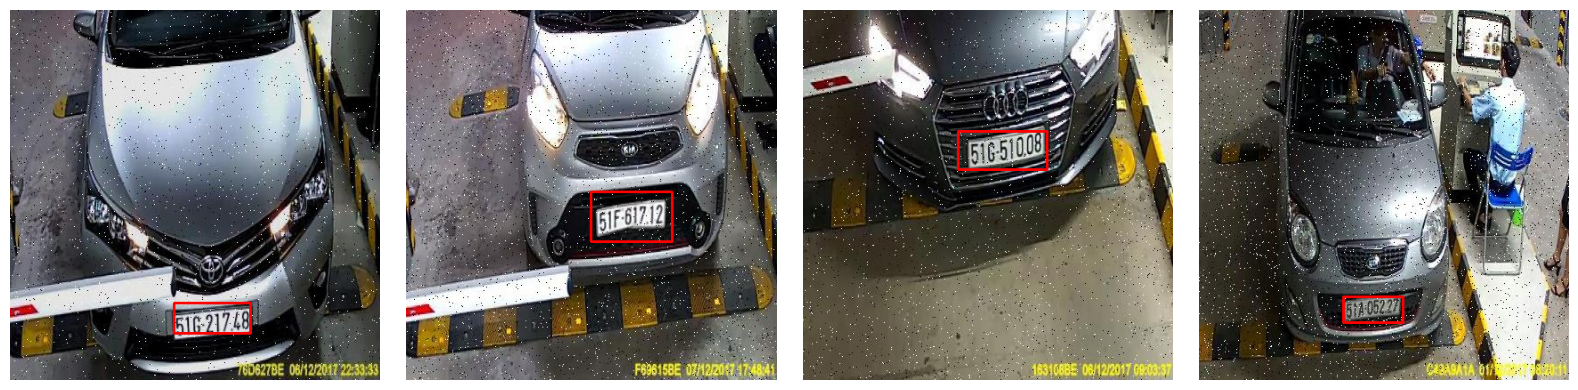

In [7]:
# Quick sanity check: visualize a few images with their YOLO bounding boxes
def show_sample(split="train", n=4):
    img_paths = list((IMAGES_DIR / split).glob("*"))[:n]
    if not img_paths:
        print(f"No images found in {split} split yet — add your dataset first.")
        return
    fig, axes = plt.subplots(1, len(img_paths), figsize=(4*len(img_paths), 4))
    if len(img_paths) == 1:
        axes = [axes]
    for ax, img_path in zip(axes, img_paths):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        label_path = LABELS_DIR / split / (img_path.stem + ".txt")
        if label_path.exists():
            for line in open(label_path):
                cls, xc, yc, bw, bh = map(float, line.split())
                x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        ax.imshow(img); ax.axis("off")
    plt.tight_layout(); plt.show()

show_sample()


## 3. Data Preprocessing & Character Segmentation

Before/alongside OCR, classical preprocessing improves recognition robustness:
- Grayscale conversion
- Contrast enhancement (CLAHE)
- Adaptive thresholding
- Contour-based character segmentation (useful as a fallback / for analysis even though the
  transformer OCR model reads the full plate crop directly).


In [8]:
def preprocess_plate(plate_img):
    """Grayscale -> CLAHE contrast enhancement -> adaptive threshold."""
    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    thresh = cv2.adaptiveThreshold(
        enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 8
    )
    return gray, enhanced, thresh


def segment_characters(thresh_img, min_area=50):
    """Contour-based character segmentation (classical fallback / diagnostics)."""
    contours, _ = cv2.findContours(thresh_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        area = w * h
        aspect_ratio = h / float(w + 1e-6)
        if area > min_area and 1.0 < aspect_ratio < 6.0:
            boxes.append((x, y, w, h))
    boxes = sorted(boxes, key=lambda b: b[0])  # left-to-right order
    return boxes


def visualize_preprocessing(plate_img):
    gray, enhanced, thresh = preprocess_plate(plate_img)
    boxes = segment_characters(thresh)
    seg_vis = cv2.cvtColor(thresh.copy(), cv2.COLOR_GRAY2BGR)
    for (x, y, w, h) in boxes:
        cv2.rectangle(seg_vis, (x, y), (x + w, y + h), (0, 255, 0), 1)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, img, title in zip(
        axes, [plate_img, gray, thresh, seg_vis],
        ["Original crop", "Grayscale + CLAHE", "Adaptive threshold", f"Segmented chars ({len(boxes)})"]
    ):
        if img.ndim == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap="gray")
        ax.set_title(title); ax.axis("off")
    plt.tight_layout(); plt.show()
    return boxes

# Example usage once you have a cropped plate image:
# plate_crop = cv2.imread("data/sample_plate_crop.jpg")
# visualize_preprocessing(plate_crop)


## 4. Stage 1 — License Plate Detection (YOLOv8)

Train a YOLOv8 model to localize license plates. This is the **detection** half of the two-stage
architecture.


In [10]:
from ultralytics import YOLO

# Start from a pretrained COCO checkpoint and fine-tune on the plate dataset (transfer learning)
detector = YOLO("yolov8n.pt")  # 'n' = nano, fastest; use 'yolov8s.pt' for better accuracy

results = detector.train(
    data=str(DATA_DIR / "data.yaml"),
    epochs=20,
    imgsz=640,
    batch=16,
    patience=10,          # early stopping
    optimizer="AdamW",
    lr0=1e-3,
    project="runs/detect",
    name="lpr_yolov8",
)


Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=lpr_yolov8-2, nbs=64, nms=False, opset=None, o

In [11]:
# Validate the trained detector
metrics = detector.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)


Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1723.8±859.1 MB/s, size: 45.2 KB)
val: Scanning /content/data/labels/val.cache... 842 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 842/842 294.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 5.4it/s 9.9s
                   all        842        864      0.995       0.97      0.987      0.828
Speed: 2.0ms preprocess, 3.9ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.9872491830981783
mAP50-95: 0.8284358620734535


In [ ]:
BEST_DETECTOR_WEIGHTS = None

# Prefer the path YOLO actually used for this training run (most reliable —
# avoids any mismatch from auto-incremented run names like "lpr_yolov8-2"
# or from project/cwd combining unexpectedly).
try:
    BEST_DETECTOR_WEIGHTS = str(Path(results.save_dir) / "weights" / "best.pt")
    if not Path(BEST_DETECTOR_WEIGHTS).exists():
        BEST_DETECTOR_WEIGHTS = None
except NameError:
    pass  # 'results' from the training cell isn't available in this session

# Fallback: search for any best.pt under runs/detect (or /content/runs/detect),
# and pick the most recently modified one.
if BEST_DETECTOR_WEIGHTS is None:
    candidates = list(Path(".").rglob("runs/detect/**/weights/best.pt"))
    if candidates:
        candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
        BEST_DETECTOR_WEIGHTS = str(candidates[0])
        print(f"Note: found weights via search, not the hardcoded path: {BEST_DETECTOR_WEIGHTS}")
    else:
        raise FileNotFoundError(
            "No trained weights found (looked for runs/detect/**/weights/best.pt). "
            "Make sure the training cell above has been run successfully first."
        )

print("Loading detector weights from:", BEST_DETECTOR_WEIGHTS)
detector = YOLO(BEST_DETECTOR_WEIGHTS)

def detect_plates(image_path, conf=0.4):
    """Run detector on an image, return list of (x1,y1,x2,y2,conf) plate boxes."""
    results_pred = detector.predict(image_path, conf=conf, verbose=False)[0]
    boxes = []
    for box in results_pred.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        boxes.append((x1, y1, x2, y2, float(box.conf[0])))
    return boxes


## 5. Stage 2 — Plate Text Recognition (Transformer OCR)

Two OCR options are wired up — pick whichever performs better on your data:
- **EasyOCR** — fast CRNN-based OCR, good baseline
- **TrOCR (transformer OCR, HuggingFace)** — attention/transformer-based recognition, matches
  your notes and generally handles varied fonts/angles better


In [13]:
import easyocr
reader = easyocr.Reader(["en"], gpu=torch.cuda.is_available())

def ocr_easyocr(plate_crop):
    result = reader.readtext(plate_crop, detail=0, paragraph=False)
    text = "".join(result).upper().replace(" ", "")
    return text


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [16]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image

trocr_processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
trocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")
trocr_model.eval()
if torch.cuda.is_available():
    trocr_model.to("cuda")

def ocr_trocr(plate_crop):
    image = Image.fromarray(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB)).convert("RGB")
    pixel_values = trocr_processor(images=image, return_tensors="pt").pixel_values
    if torch.cuda.is_available():
        pixel_values = pixel_values.to("cuda")
    generated_ids = trocr_model.generate(pixel_values, max_new_tokens=16)
    text = trocr_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return text.upper().replace(" ", "")


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.13k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

ValueError: Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.

In [17]:
import re

INDIAN_PLATE_REGEX = re.compile(r"^[A-Z]{2}[0-9]{1,2}[A-Z]{1,3}[0-9]{4}$")

def clean_and_validate(text):
    """Strip non-alphanumeric chars, uppercase, check against Indian plate format."""
    cleaned = re.sub(r"[^A-Z0-9]", "", text.upper())
    is_valid = bool(INDIAN_PLATE_REGEX.match(cleaned))
    return cleaned, is_valid


## 6. Full Two-Stage Pipeline (Detection → Recognition)

In [18]:
def recognize_plate(image_path, ocr_engine="trocr", conf=0.4, show=False):
    """End-to-end: detect plate(s) in an image, run OCR on each crop, validate format."""
    image = cv2.imread(image_path)
    boxes = detect_plates(image_path, conf=conf)

    results = []
    for (x1, y1, x2, y2, det_conf) in boxes:
        crop = image[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        raw_text = ocr_trocr(crop) if ocr_engine == "trocr" else ocr_easyocr(crop)
        cleaned, is_valid = clean_and_validate(raw_text)
        results.append({
            "bbox": (x1, y1, x2, y2),
            "det_conf": det_conf,
            "raw_text": raw_text,
            "plate_text": cleaned,
            "valid_format": is_valid,
        })

    if show:
        vis = image.copy()
        for r in results:
            x1, y1, x2, y2 = r["bbox"]
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(vis, r["plate_text"], (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

    return results

# Example:
# recognize_plate("data/images/test/sample.jpg", ocr_engine="trocr", show=True)


## 6b. Quick Test — Upload Your Own Image


In [ ]:
# Upload an image from your computer (Colab file picker) and run the
# full detection + OCR pipeline on it, using EasyOCR.
from google.colab import files

uploaded = files.upload()  # opens a file picker; select one image

if not uploaded:
    print("No file uploaded.")
else:
    test_image_path = list(uploaded.keys())[0]
    print(f"Testing on: {test_image_path}")

    test_results = recognize_plate(test_image_path, ocr_engine="easyocr", conf=0.4, show=True)

    if not test_results:
        print("No license plate detected. Try a clearer/closer image, or lower conf (e.g. conf=0.25).")
    else:
        for i, r in enumerate(test_results):
            status = "VALID format" if r["valid_format"] else "format not recognized"
            print(f"Plate {i+1}: '{r['plate_text']}'  (raw OCR: '{r['raw_text']}', "
                  f"detector conf: {r['det_conf']:.2f}, {status})")


## 7. Training & Optimization Notes

- **Augmentation**: YOLOv8's built-in augmentations (mosaic, HSV jitter, flip) help generalize
  across lighting/angle. Disable horizontal flip if plate text orientation matters (it does).
- **Learning rate schedule**: cosine decay with warmup (`ultralytics` handles this via `lr0`/`lrf`).
- **Early stopping**: `patience` parameter above stops training when val mAP plateaus.
- **Model size trade-off**: `yolov8n` (nano) for real-time speed vs `yolov8s/m` for accuracy —
  benchmark both if latency is a hard constraint (e.g. toll booths).
- **OCR fine-tuning**: TrOCR can be fine-tuned on cropped plate images + ground-truth text using
  HuggingFace `Trainer` if pretrained accuracy isn't sufficient for your dataset's fonts.


In [19]:
# Disable flip augmentation explicitly when re-training (text orientation matters for plates)
# detector.train(data=str(DATA_DIR / "data.yaml"), epochs=50, imgsz=640, fliplr=0.0, flipud=0.0)


## 8. Evaluation Metrics

- **Detection**: mAP@0.5, mAP@0.5:0.95, IoU (from YOLO's built-in validation) — computable directly on the Kaggle dataset since it ships bounding-box labels.
- **Recognition**: Character-level accuracy, full plate (exact match) accuracy — requires a `test_labels.csv` with the *actual plate text* per image. The Kaggle dataset used above only has bounding boxes, not transcribed text, so build this CSV by hand-labeling a small held-out sample (e.g. 50-100 test-split images) before running `evaluate_recognition` below.
- **End-to-end**: Correct detections + correct OCR / total plates


In [20]:
def char_accuracy(pred, gt):
    """Character-level accuracy between predicted and ground-truth plate strings."""
    if not gt:
        return 0.0
    matches = sum(1 for p, g in zip(pred, gt) if p == g)
    return matches / max(len(pred), len(gt))


def evaluate_recognition(test_csv):
    """test_csv: columns ['image_path', 'ground_truth_plate']"""
    df = pd.read_csv(test_csv)
    char_accs, exact_matches = [], []
    for _, row in df.iterrows():
        preds = recognize_plate(row["image_path"], ocr_engine="trocr")
        pred_text = preds[0]["plate_text"] if preds else ""
        gt = row["ground_truth_plate"].upper()
        char_accs.append(char_accuracy(pred_text, gt))
        exact_matches.append(int(pred_text == gt))

    print(f"Mean character accuracy: {np.mean(char_accs):.3f}")
    print(f"Exact plate match accuracy: {np.mean(exact_matches):.3f}")
    return df.assign(char_acc=char_accs, exact_match=exact_matches)

# evaluate_recognition("data/test_labels.csv")


## 9. Real-Time Inference (Video) & Deployment Notes

The function below runs the pipeline on video frames and reports FPS — the key metric for
real-time use cases like **toll collection** and **traffic monitoring**. No web frontend is
included here (notebook/CLI only, per project scope) — this function is what a deployment
service would wrap.


In [21]:
def run_on_video(video_path, ocr_engine="trocr", conf=0.4, frame_skip=2, max_frames=None):
    cap = cv2.VideoCapture(video_path)
    frame_idx = 0
    processed = 0
    detections_log = []
    start_time = time.time()

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % frame_skip == 0:
            tmp_path = "_tmp_frame.jpg"
            cv2.imwrite(tmp_path, frame)
            results = recognize_plate(tmp_path, ocr_engine=ocr_engine, conf=conf)
            for r in results:
                r["frame"] = frame_idx
                detections_log.append(r)
            processed += 1
            if max_frames and processed >= max_frames:
                break
        frame_idx += 1

    cap.release()
    elapsed = time.time() - start_time
    fps = processed / elapsed if elapsed > 0 else 0
    print(f"Processed {processed} frames in {elapsed:.2f}s ({fps:.2f} FPS)")
    return pd.DataFrame(detections_log)

In [22]:


results_df = run_on_video("data/sample_traffic.mp4", frame_skip=3, max_frames=100)


Processed 0 frames in 0.00s (0.00 FPS)


### Deployment considerations
- **Toll collection**: pair detections with a vehicle-class check (car/truck/bike) and log to a
  billing DB; require format validation (`valid_format`) before charging.
- **Traffic monitoring**: run at reduced frame rate (`frame_skip`) on live camera feeds; log
  plate + timestamp + camera ID for downstream analytics (speed, congestion, violations).
- **Latency budget**: nano YOLO + EasyOCR is fastest; TrOCR is more accurate but slower —
  benchmark both on your target hardware (edge device vs server) before choosing.
- **Privacy**: plate data is PII in most jurisdictions — hash/encrypt at rest, restrict retention.

